# Script to align DEMs, clip to glacier polygons, and difference
## Produces glacier elevation loss 

### Code produced by Emma Tyrrell and Millie Spencer

In [1]:
# ------------------------------------------------------------------------------
# Import required modules
# ------------------------------------------------------------------------------
import arcpy
from arcpy import env
from arcpy.sa import *
import os
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

print("Modules imported")

# ------------------------------------------------------------------------------
# USER VARIABLES: Update these paths and names as needed
# ------------------------------------------------------------------------------
baseline_str = "IGM"
polygon = "2019"
raster_folder = r"C:/Users/etyrr/OneDrive/Documents/CU_Grad/MillieWorkflow/dems_take2/"
polygon_clips = rf"C:\Users\etyrr\OneDrive\Documents\CU_Grad\MillieWorkflow\data\polygons\Nevados_polygons_DGA{polygon}.shp"
stats_field = "COD_GLA"
snapRaster = r"C:\Users\etyrr\OneDrive\Documents\CU_Grad\MillieWorkflow\coreg\SRTM_projected_raster.tif"
outputFolder = f"C:/Users/etyrr/OneDrive/Documents/CU_Grad/MillieWorkflow/dems_take2/output_data_base{baseline_str}_poly{polygon}/"
slope = r"C:\Users\etyrr\OneDrive\Documents\CU_Grad\MillieWorkflow\data\surfParameters\SRTM_slope.tif"
aspect = r"C:\Users\etyrr\OneDrive\Documents\CU_Grad\MillieWorkflow\data\surfParameters\SRTM_aspect.tif"

# ------------------------------------------------------------------------------
# Set baseline raster path
# ------------------------------------------------------------------------------
if baseline_str == "SRTM":
    baseline_raster = r"C:\Users\etyrr\OneDrive\Documents\CU_Grad\MillieWorkflow\SRTM_projected_raster.tif"
elif baseline_str == "IGM":
    baseline_raster = r"C:\Users\etyrr\OneDrive\Documents\CU_Grad\MillieWorkflow\dems_take2\IGM1954_DEMprojected_SRTM_DEMprojected_nuth_x-34.95_y-8.24_z-9.95_align.tif"
else:
    raise ValueError("Unknown baseline_str provided.")

# ------------------------------------------------------------------------------
# Make output folder
# ------------------------------------------------------------------------------
if not os.path.exists(outputFolder):
    os.mkdir(outputFolder)
    print("Output folder created")

# ------------------------------------------------------------------------------
# Logging and confirmation
# ------------------------------------------------------------------------------
print("MODEL OUTPUTS TO BE PRINTED TO THIS DOC")
print(f"\n Baseline Raster: {baseline_raster}")
print(f"\n SnapRaster: {snapRaster}")
print(f"\n Polygons Clips: {polygon_clips}")
print(f"\n Polygon Field: {stats_field}")
print("Differencing: Current Raster - Baseline Raster")
print("PROCESSING STARTS")
print("##########################################################")

# ------------------------------------------------------------------------------
# Clip input DEMs to polygons
# ------------------------------------------------------------------------------
for filename in os.listdir(raster_folder):
    if filename.endswith('.tif') and not filename.endswith('clp.tif'):
        full_path = os.path.join(raster_folder, filename)
        print(f"\n Processing: {full_path}")

        arcpy.env.snapRaster = snapRaster
        outExtract = ExtractByMask(full_path, polygon_clips, "INSIDE")
        outExtract.save(os.path.join(outputFolder, f"{filename[:20]}_clp.tif"))
        print(f"{filename} clipped and saved to output directory")

# ------------------------------------------------------------------------------
# Subtract clipped rasters from baseline
# ------------------------------------------------------------------------------
for tif in os.listdir(outputFolder):
    if tif.endswith('clp.tif'):
        full_path = os.path.join(outputFolder, tif)
        arcpy.env.snapRaster = snapRaster

        try:
            current_raster = Raster(full_path)
            Difference = current_raster - Raster(baseline_raster)

            output_name = f"{tif[:-4]}_diff.tif"
            output_path = os.path.join(outputFolder, output_name)
            Difference.save(output_path)
        except Exception as ex:
            print(f"Error processing {tif}: {ex}")

# ------------------------------------------------------------------------------
# Run Zonal Statistics on differenced rasters
# ------------------------------------------------------------------------------
for dif in os.listdir(outputFolder):
    if dif.endswith('diff.tif'):
        full_path = os.path.join(outputFolder, dif)
        stats_table = os.path.join(outputFolder, f"{dif[:-4]}_zonalStats.dbf")
        csv_path = os.path.join(outputFolder, f"{dif[:-4]}_zonalStats.csv")

        outZonalStats = ZonalStatisticsAsTable(polygon_clips, stats_field, full_path, stats_table, "DATA")
        arcpy.ExportTable_conversion(stats_table, csv_path)

# ------------------------------------------------------------------------------
# Run Zonal Stats for aspect and slope
# ------------------------------------------------------------------------------
arcpy.env.snapRaster = snapRaster
aspect_table = os.path.join(outputFolder, "Polygon_zonalStats_aspect.dbf")
slope_table = os.path.join(outputFolder, "Polygon_zonalStats_slope.dbf")

ZonalStatisticsAsTable(polygon_clips, stats_field, aspect, aspect_table, "", "ALL")
ZonalStatisticsAsTable(polygon_clips, stats_field, slope, slope_table, "", "ALL")

# Export to CSV
arcpy.ExportTable_conversion(aspect_table, aspect_table.replace(".dbf", ".csv"))
arcpy.ExportTable_conversion(slope_table, slope_table.replace(".dbf", ".csv"))
print("Tables exported for zonal stats")

# ------------------------------------------------------------------------------
# Merge aspect/slope stats into zonal stats
# ------------------------------------------------------------------------------
df_aspect = pd.read_csv(aspect_table.replace(".dbf", ".csv"))
df_aspect = df_aspect.rename(columns={"MIN": "Asp_MIN", "MAX": "Asp_MAX", "MEAN": "Asp_MEAN"})
df_aspect = df_aspect[["COD_GLA", "Asp_MIN", "Asp_MAX", "Asp_MEAN"]]

df_slope = pd.read_csv(slope_table.replace(".dbf", ".csv"))
df_slope = df_slope.rename(columns={"MIN": "Slp_MIN", "MAX": "Slp_MAX", "MEAN": "Slp_MEAN"})
df_slope = df_slope[["COD_GLA", "Slp_MIN", "Slp_MAX", "Slp_MEAN"]]

for csv in os.listdir(outputFolder):
    if csv.endswith('zonalStats.csv'):
        full_path = os.path.join(outputFolder, csv)
        df_poly = pd.read_csv(full_path)

        merged_df = pd.merge(df_poly, df_aspect, on="COD_GLA", how='inner')
        merged_df = pd.merge(merged_df, df_slope, on="COD_GLA", how='inner')
        merged_df.to_csv(full_path.replace(".csv", "_merged.csv"), index=False)

# ------------------------------------------------------------------------------
# Generate comparison plots of the first 3 diff rasters
# ------------------------------------------------------------------------------
raster_files = sorted([f for f in os.listdir(outputFolder) if f.endswith('diff.tif')])[:3]

all_data = []
all_extents = []

for map in raster_files:
    with rasterio.open(os.path.join(outputFolder, map)) as src:
        data = src.read(1)
        nodata = src.nodata
        data = np.where(data == nodata, np.nan, data)
        all_data.append(data)
        all_extents.append([
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ])

vmin = np.nanmin([np.nanmin(data) for data in all_data])
vmax = np.nanmax([np.nanmax(data) for data in all_data])
common_extent = [
    min(e[0] for e in all_extents),
    max(e[1] for e in all_extents),
    min(e[2] for e in all_extents),
    max(e[3] for e in all_extents)
]

# Plot
fig, axes = plt.subplots(1, len(raster_files), figsize=(18, 6))
for ax, map, data in zip(axes, raster_files, all_data):
    cmap = plt.get_cmap('RdBu_r')
    abs_max = max(abs(vmin), abs(vmax))
    im = ax.imshow(data, cmap=cmap, extent=common_extent, vmin=-abs_max, vmax=abs_max)
    ax.set_title(map)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8, pad=0.02)
cbar.set_label('Elevation Change (m)')

plt.tight_layout()
plt.subplots_adjust(right=0.75)
plt.savefig(os.path.join(outputFolder, "Updated_graphic.png"))
plt.show()


ModuleNotFoundError: No module named 'arcpy'

## Script to make box plot of mass balance results

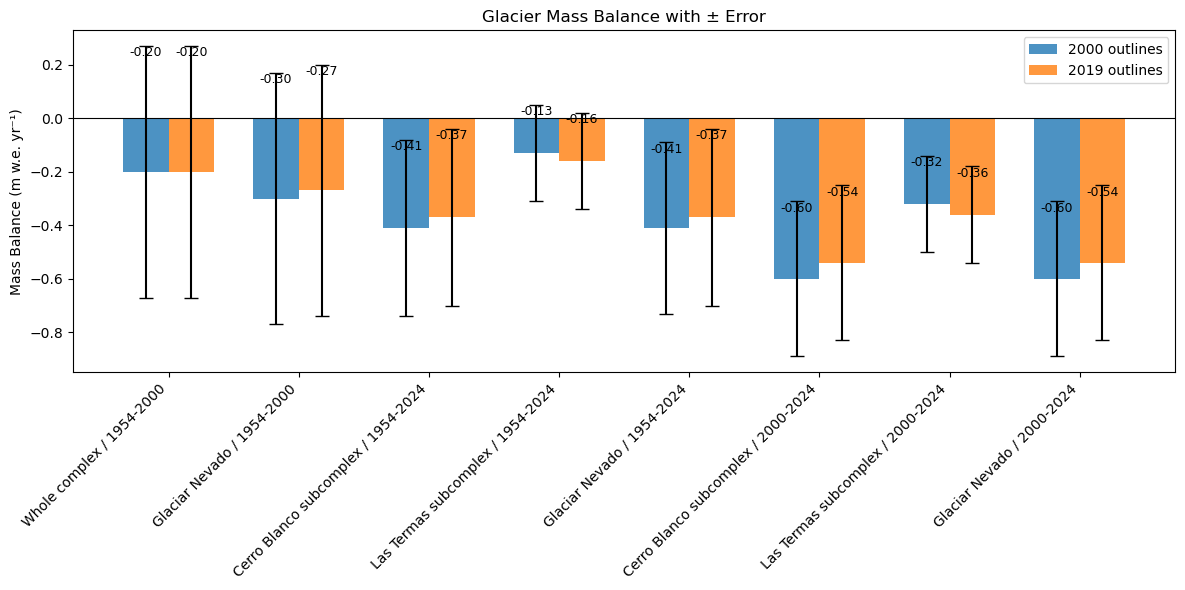

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Define the datasets
# ----------------------------
data_2000 = {
    "Glacier/Year": [
        "Whole complex / 1954-2000",
        "Glaciar Nevado / 1954-2000",
        "Cerro Blanco subcomplex / 1954-2024",
        "Las Termas subcomplex / 1954-2024",
        "Glaciar Nevado / 1954-2024",
        "Cerro Blanco subcomplex / 2000-2024",
        "Las Termas subcomplex / 2000-2024",
        "Glaciar Nevado / 2000-2024"
    ],
    "MB": [-0.2, -0.3, -0.41, -0.13, -0.41, -0.6, -0.32, -0.6],
    "Error": [0.47, 0.47, 0.33, 0.18, 0.32, 0.29, 0.18, 0.29]
}

data_2019 = {
    "Glacier/Year": [
        "Whole complex / 1954-2000",
        "Glaciar Nevado / 1954-2000",
        "Cerro Blanco subcomplex / 1954-2024",
        "Las Termas subcomplex / 1954-2024",
        "Glaciar Nevado / 1954-2024",
        "Cerro Blanco subcomplex / 2000-2024",
        "Las Termas subcomplex / 2000-2024",
        "Glaciar Nevado / 2000-2024"
    ],
    "MB": [-0.2, -0.27, -0.37, -0.16, -0.37, -0.54, -0.36, -0.54],
    "Error": [0.47, 0.47, 0.33, 0.18, 0.33, 0.29, 0.18, 0.29]
}

df2000 = pd.DataFrame(data_2000)
df2019 = pd.DataFrame(data_2019)

# ----------------------------
# Plot grouped bar chart
# ----------------------------
x = np.arange(len(df2000))  # positions
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(12,6))

# Bars for each dataset
bars1 = ax.bar(x - width/2, df2000["MB"], width, yerr=df2000["Error"],
               capsize=5, label="2000 outlines", alpha=0.8)
bars2 = ax.bar(x + width/2, df2019["MB"], width, yerr=df2019["Error"],
               capsize=5, label="2019 outlines", alpha=0.8)

# Labels & formatting
ax.set_ylabel("Mass Balance (m w.e. yr⁻¹)")
ax.set_title("Glacier Mass Balance with ± Error")
ax.set_xticks(x)
ax.set_xticklabels(df2000["Glacier/Year"], rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8)  # baseline at 0
ax.legend()

# ----------------------------
# Add labels above error bars
# ----------------------------
def add_labels(bars, errors):
    for bar, err in zip(bars, errors):
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        # Position label just above the error bar
        ax.text(x, height - np.sign(height)*err - 0.05,  # offset slightly
                f"{height:.2f}", ha="center", va="bottom", fontsize=9)

add_labels(bars1, df2000["Error"])
add_labels(bars2, df2019["Error"])

plt.tight_layout()
plt.show()


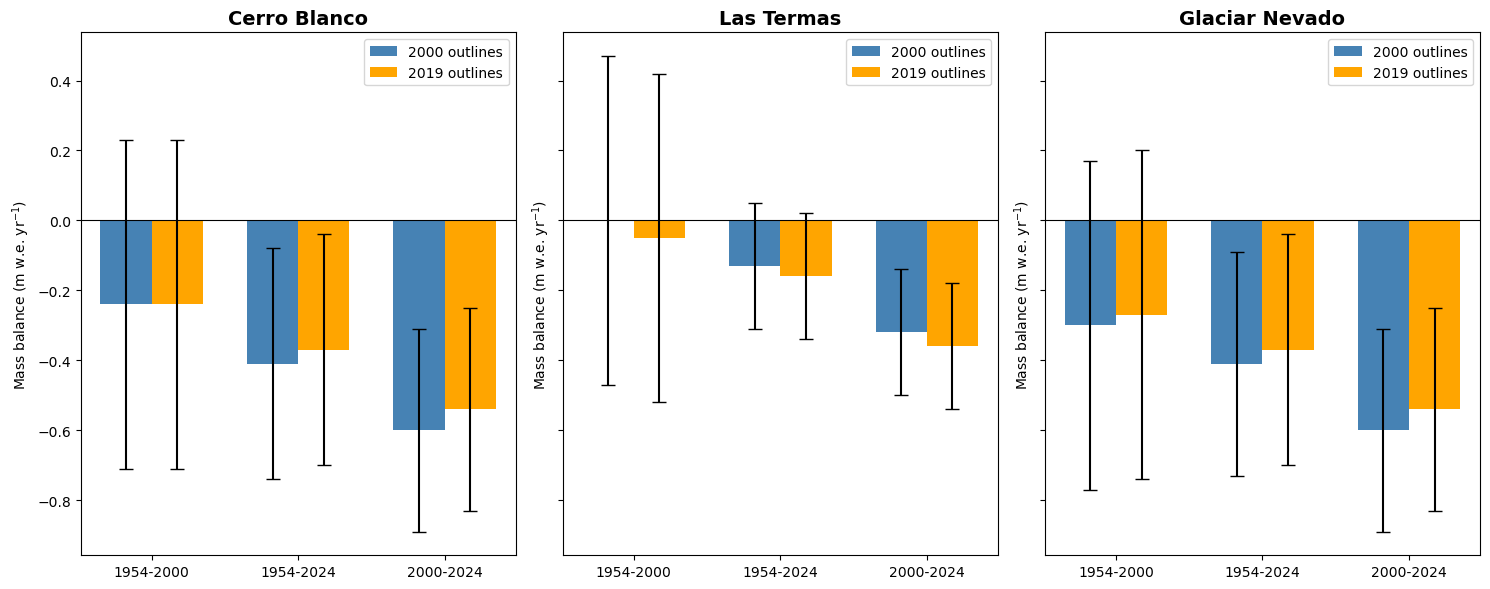

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --------------------------
# Input data
# --------------------------

data_2000 = {
    "Glacier": ["Cerro Blanco", "Cerro Blanco", "Cerro Blanco",
                "Las Termas", "Las Termas", "Las Termas",
                "Glaciar Nevado", "Glaciar Nevado", "Glaciar Nevado"],
    "Period": ["1954-2000", "1954-2024", "2000-2024",
               "1954-2000", "1954-2024", "2000-2024",
               "1954-2000", "1954-2024", "2000-2024"],
    "MB": [-0.24, -0.41, -0.60,
           0.00, -0.13, -0.32,
           -0.30, -0.41, -0.60],
    "Error": [0.47, 0.33, 0.29,
              0.47, 0.18, 0.18,
              0.47, 0.32, 0.29]
}

data_2019 = {
    "Glacier": ["Cerro Blanco", "Cerro Blanco", "Cerro Blanco",
                "Las Termas", "Las Termas", "Las Termas",
                "Glaciar Nevado", "Glaciar Nevado", "Glaciar Nevado"],
    "Period": ["1954-2000", "1954-2024", "2000-2024",
               "1954-2000", "1954-2024", "2000-2024",
               "1954-2000", "1954-2024", "2000-2024"],
    "MB": [-0.24, -0.37, -0.54,
           -0.05, -0.16, -0.36,
           -0.27, -0.37, -0.54],
    "Error": [0.47, 0.33, 0.29,
              0.47, 0.18, 0.18,
              0.47, 0.33, 0.29]
}

df2000 = pd.DataFrame(data_2000)
df2019 = pd.DataFrame(data_2019)

# --------------------------
# Plotting function
# --------------------------

def plot_glacier_comparison(glacier_name, ax):
    # Subset data
    d1 = df2000[df2000["Glacier"] == glacier_name]
    d2 = df2019[df2019["Glacier"] == glacier_name]

    # Define x locations
    x = np.arange(len(d1["Period"]))  # 3 periods
    width = 0.35  # bar width

    # Bars for 2000 outlines
    ax.bar(x - width/2, d1["MB"], width, yerr=d1["Error"], 
           capsize=5, label="2000 outlines", color="steelblue")

    # Bars for 2019 outlines
    ax.bar(x + width/2, d2["MB"], width, yerr=d2["Error"], 
           capsize=5, label="2019 outlines", color="orange")

    # Formatting
    ax.set_title(glacier_name, fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(d1["Period"])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Mass balance (m w.e. yr$^{-1}$)")
    ax.legend()

# --------------------------
# Make figure with 3 panels
# --------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

glaciers = ["Cerro Blanco", "Las Termas", "Glaciar Nevado"]
for ax, g in zip(axes, glaciers):
    plot_glacier_comparison(g, ax)

plt.tight_layout()
plt.show()
